# EEG Person Identification using CNN - Local Version (Memory Optimized)

This notebook is adapted from the Colab version to run locally.

**Update:** This version uses `tf.data.Dataset` generators to avoid MemoryErrors by streaming data instead of loading it all into RAM.

**Configuration:**
- Update `DATASET_PATH` and `OUTPUT_DIR` in the cell below to point to your local dataset and output directories.

## 1. Configuration & Setup

In [ ]:
import os

# ============== CONFIGURATION ==============
# Update these paths to your local dataset and output folders
DATASET_PATH = os.environ.get("EEG_DATASET_PATH", "./data/files")
OUTPUT_DIR = os.environ.get("EEG_OUTPUT_DIR", "./output")
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

# Create output directories if they don't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"Dataset path: {DATASET_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Dataset exists: {os.path.exists(DATASET_PATH)}")

## 2. Import Libraries

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import h5py
import pyedflib
from tqdm import tqdm
import time
import glob

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 3. Define CNN Model

In [ ]:
def CNN():
    input_shape = (160, 64)

    model = models.Sequential()

    model.add(layers.BatchNormalization(input_shape=input_shape, epsilon=.0001))
    
    model.add(layers.Conv1D(input_shape=input_shape, activation='relu', filters=128, kernel_size=2, strides=1, padding='same'))
    model.add(layers.MaxPooling1D(pool_size=2, strides=2, padding='same'))

    model.add(layers.Conv1D(input_shape=(80, 128), activation='relu', filters=256, kernel_size=2, strides=1, padding='same'))
    model.add(layers.MaxPooling1D(pool_size=2, strides=2, padding='same'))

    model.add(layers.Conv1D(input_shape=(40, 256), activation='relu', filters=512, kernel_size=2, strides=1, padding='same'))
    model.add(layers.MaxPooling1D(pool_size=2, strides=2, padding='same'))
    model.add(layers.Conv1D(input_shape=(20, 512), activation='relu', filters=1024, kernel_size=2, strides=1, padding='same'))
    model.add(layers.MaxPooling1D(pool_size=2, strides=2, padding='same'))

    model.add(layers.Reshape((-1, 64*160), input_shape=(80, 10, 1024)))
    model.add(layers.Dropout(rate=0.5, input_shape=(80, 10240)))
    
    model.add(tf.keras.layers.Dense(109, activation='softmax'))

    model.summary()
    return model

## 4. Define Data Loading Functions (Generator Based)

In [4]:
def _read_py_function(filename):
    """Read EDF file and extract EEG data with labels."""
    # Handle both string and bytes (TF Dataset can pass bytes)
    if isinstance(filename, bytes):
        filename = filename.decode()
    elif hasattr(filename, 'numpy'):
        filename = filename.numpy().decode()
    
    f = pyedflib.EdfReader(filename)
    n_channels = f.signals_in_file
    n_samples_arr = f.getNSamples()
    eeg_data = np.zeros((n_channels, n_samples_arr[0]), dtype=np.float32)
    for i in np.arange(n_channels):
        eeg_data[i, :] = f.readSignal(i)

    n_samples = n_samples_arr[0]
    f.close()  # Important: close the file after reading
    
    reminder = int(n_samples % 160)
    n_samples -= reminder
    seconds = int(n_samples/160)  # 160 is frequency
    
    # Extract person ID from filename
    path_parts = filename.replace("\\", "/").split("/")
    person_filename = path_parts[-1]
    person_id = int(person_filename.partition("S")[2].partition("R")[0])
    
    label = np.zeros(109, dtype=bool)  # 109 classes (persons)
    label[person_id-1] = 1
    labels = np.tile(label, (seconds, 1))
    
    eeg_data = eeg_data.transpose()
    if reminder > 0:
        eeg_data = eeg_data[:-reminder, :]
    intervals = np.linspace(0, n_samples, num=seconds, endpoint=False, dtype=int)
    eeg_data = np.split(eeg_data, intervals)
    del eeg_data[0]
    eeg_data = np.array(eeg_data)  # shape = (seconds, frequency, n_channels)

    return eeg_data, labels

In [5]:
def data_generator(files):
    """Generator that yields (sample, label) pairs."""
    for filename in files:
        try:
            eeg_data, labels = _read_py_function(filename)
            # eeg_data shape: (seconds, 160, 64)
            # labels shape: (seconds, 109)
            
            for i in range(len(eeg_data)):
                # Yield single sample and label
                yield eeg_data[i], np.expand_dims(labels[i], axis=0)
        except Exception as e:
            print(f"Error reading {filename}: {e}")

def get_tf_dataset(dataset_type="train", batch_size=80, shuffle=True):
    """
    Create a tf.data.Dataset for training/testing.
    """
    path = DATASET_PATH
    
    if dataset_type == "train":
        files = []
        for i in range(1, 13):
            pattern = os.path.join(path, "S*", f"S*R{i:02d}.edf")
            files.extend(glob.glob(pattern))
    elif dataset_type == "test":
        pattern = os.path.join(path, "S*", "S*R13.edf")
        files = glob.glob(pattern)
    elif dataset_type == "validation":
        pattern = os.path.join(path, "S*", "S*R14.edf")
        files = glob.glob(pattern)
    else:
        raise ValueError(f"Unknown dataset_type: {dataset_type}")
    
    print(f"Found {len(files)} files for {dataset_type}")
    
    # Create dataset from generator
    # Output signature must match yield format
    output_signature = (
        tf.TensorSpec(shape=(160, 64), dtype=tf.float32),
        tf.TensorSpec(shape=(1, 109), dtype=tf.bool) # Matching original (1, 109) data shape
    )
    
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(files),
        output_signature=output_signature
    )
    
    if shuffle:
        # Shuffle buffer size - adjust based on memory
        # 10000 samples is roughly 80MB, so safe
        dataset = dataset.shuffle(10000)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

## 5. Prepare Datasets

Now we create the dataset objects. This does **not** load the data yet. Data will be streamed during training.

In [6]:
train_dataset = get_tf_dataset(dataset_type="train", batch_size=80, shuffle=True)
test_dataset = get_tf_dataset(dataset_type="test", batch_size=80, shuffle=False)

print("Datasets prepared.")

Found 1308 files for train
Found 109 files for test
Datasets prepared.


## 6. Create and Compile Model

In [7]:
model = CNN()

tf.keras.optimizers.Adam(learning_rate=0.00001)

model.compile(optimizer='adam',
          loss=tf.keras.losses.CategoricalCrossentropy(),
          metrics=['accuracy'])

c:\Users\moust\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\moust\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\moust\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 160, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 160, 128)       │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 80, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 80, 256)        │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 40, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 40, 512)        │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 20, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 20, 1024)       │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 10, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 10240)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 10240)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1, 109)         │     1,116,269 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,511,085 (9.58 MB)

 Trainable params: 2,510,957 (9.58 MB)

 Non-trainable params: 128 (512.00 B)

## 7. Setup Checkpoints and Train

In [8]:
# UPDATE: Use .weights.h5 for Keras 3+ weight-only saving
checkpoint_path = os.path.join(CHECKPOINT_DIR, "cp-{epoch:04d}.weights.h5")
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)
model.save_weights(checkpoint_path.format(epoch=0))
print(f"Checkpoints will be saved to: {CHECKPOINT_DIR}")

Checkpoints will be saved to: C:\Users\moust\OneDrive\سطح المكتب\GRAD PROJECT\output\checkpoints


In [9]:
# Train the model using the tf.data.Dataset
history = model.fit(train_dataset, 
                    epochs=50, 
                    validation_data=test_dataset, 
                    callbacks=[cp_callback])

Epoch 1/50
   1839/Unknown 843s 444ms/step - accuracy: 0.4636 - loss: 2.0801

c:\Users\moust\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: saving model to C:\Users\moust\OneDrive\سطح المكتب\GRAD PROJECT\output\checkpoints\cp-0001.weights.h5
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 883s 466ms/step - accuracy: 0.6695 - loss: 1.1779 - val_accuracy: 0.8498 - val_loss: 0.5385
Epoch 2/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8386 - loss: 0.5562
Epoch 2: saving model to C:\Users\moust\OneDrive\سطح المكتب\GRAD PROJECT\output\checkpoints\cp-0002.weights.h5
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 808s 424ms/step - accuracy: 0.8895 - loss: 0.3652 - val_accuracy: 0.9086 - val_loss: 0.3911
Epoch 3/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8966 - loss: 0.3576
Epoch 3: saving model to C:\Users\moust\OneDrive\سطح المكتب\GRAD PROJECT\output\checkpoints\cp-0003.weights.h5
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 812s 436ms/step - accuracy: 0.9263 - loss: 0.2442 - val_accuracy: 0.9320 - val_loss: 0.2645
Epoch 4/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9180 - loss: 0.2804
Epoch 4: saving model to C:

## 8. Save and Load History

In [10]:
history_path = os.path.join(OUTPUT_DIR, 'history.npy')
np.save(history_path, history.history)
print(f"History saved to: {history_path}")

History saved to: C:\Users\moust\OneDrive\سطح المكتب\GRAD PROJECT\output\history.npy


## 9. Plot Training Results

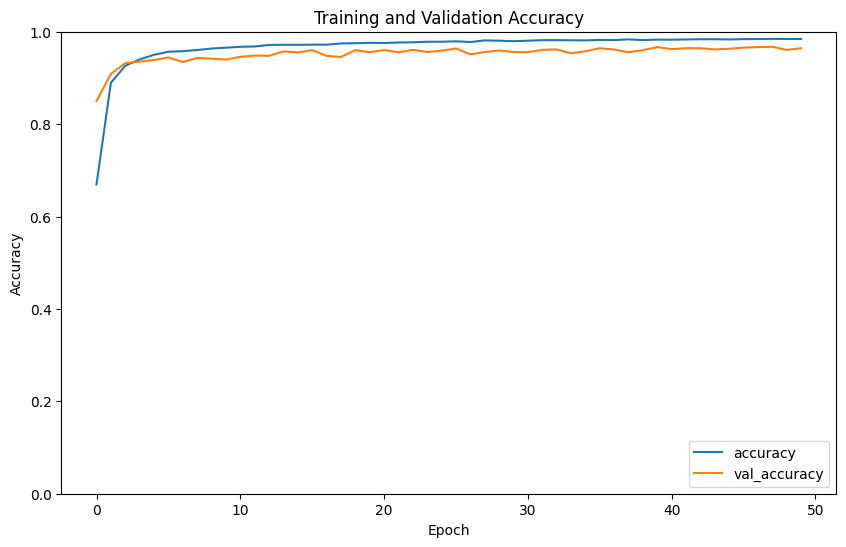

In [11]:
if type(history) is not dict:
    hist = history.history
else:
    hist = history

plt.figure(figsize=(10, 6))
plt.plot(hist['accuracy'], label='accuracy')
plt.plot(hist['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.savefig(os.path.join(OUTPUT_DIR, 'training_history.png'))
plt.show()

## 10. Load Best Checkpoint

In [12]:
if type(history) is not dict:
    hist = history.history
else:
    hist = history

max_value = max(hist['val_accuracy'])
print(f"Best validation accuracy: {max_value}")
max_index = hist['val_accuracy'].index(max_value)
print(f"Best epoch: {max_index}")

best_checkpoint_path = os.path.join(CHECKPOINT_DIR, f"cp-{max_index:04d}.weights.h5")
model.load_weights(best_checkpoint_path)

Best validation accuracy: 0.9674887657165527
Best epoch: 47


## 11. Evaluate Model

In [13]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

168/168 ━━━━━━━━━━━━━━━━━━━━ 23s 138ms/step - accuracy: 0.9667 - loss: 0.4116
Test Loss: 0.4116380214691162
Test Accuracy: 0.9666666388511658


## 12. Confusion Matrix & Metrics

In [14]:
# To compute metrics manually, we need to iterate over the dataset to get all predictions
print("Generating predictions...")
y_pred_list = []
y_true_list = []

for x_batch, y_batch in tqdm(test_dataset):
    pred_batch = model.predict(x_batch, verbose=0)
    y_pred_list.extend(np.argmax(pred_batch, axis=2).flatten())
    y_true_list.extend(np.argmax(y_batch, axis=2).flatten())

y_pred = np.array(y_pred_list)
y_test = np.array(y_true_list)

print(f"Total samples: {len(y_pred)}")

Generating predictions...


168it [00:25,  6.70it/s]

Total samples: 13380


In [15]:
correct = np.sum(y_pred == y_test)
accuracy = correct / len(y_test)
print(f"Calculated Accuracy: {accuracy}")

Calculated Accuracy: 0.9666666666666667


In [16]:
results = np.column_stack((y_test, y_pred))
# Calculate FAR, FRR
from statistics import mean

frrs = list()
fars = list()

for s in range(0, 109):
    # Samples that are actually class s
    actual_s = results[results[:,0] == s]
    # Samples predicted as class s
    pred_s = results[results[:,1] == s]
    
    # False Rejection: Actual is s, but predicted != s
    # frr = (False Negatives) / (Total Actual Positives)
    total_actual_pos = len(actual_s)
    if total_actual_pos > 0:
        false_neg = len(actual_s[actual_s[:,1] != s])
        frrs.append(false_neg / total_actual_pos)
    
    # False Acceptance: Predicted is s, but Actual != s
    # far = (False Positives) / (Total Predicted Positives)
    total_pred_pos = len(pred_s)
    if total_pred_pos > 0:
        false_pos = len(pred_s[pred_s[:,0] != s])
        fars.append(false_pos / total_pred_pos)

FAR_mean = mean(fars) if fars else 0
FRR_mean = mean(frrs) if frrs else 0
eer = (FRR_mean + FAR_mean)/2

print(f"FAR: {FAR_mean}")
print(f"FRR: {FRR_mean}")
print(f"EER: {eer}")

FAR: 0.032132051017843215
FRR: 0.033610080798292884
EER: 0.03287106590806805


In [17]:
model.save(os.path.join(OUTPUT_DIR, 'final_model.keras'))
print("Model saved.")

Model saved.
